# Sentiment Analysis Model Training

This notebook focuses on the machine learning phase of the project.

The cleaned IMDb movie reviews are converted into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**. These features are then used to train and evaluate different sentiment classification models.

The workflow includes:

1. Loading the cleaned dataset
2. Feature Engineering using TF-IDF
3. Splitting the dataset
4. Training Machine Learning models
5. Model Evaluation
6. Model Comparison

## Import Required Libraries

In [4]:
import sys
import os

import pandas as pd

In [5]:
sys.path.append(os.path.abspath("../src"))

In [6]:
from feature_engineering import (
    create_vectorizer,
    fit_transform_reviews,
    save_vectorizer
)

## Load the Clean Dataset

In [7]:
df = pd.read_csv("../data/clean_imdb_reviews.csv")

df.head()

,review,sentiment,review_length,clean_review
0,One of the other reviewers has mentioned that ...,positive,1761,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,positive,998,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,926,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,748,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,petter matteis love time money visually stunni...


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   review         50000 non-null  str  
 1   sentiment      50000 non-null  str  
 2   review_length  50000 non-null  int64
 3   clean_review   50000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 103.5 MB


## TF-IDF Feature Engineering

Machine learning models cannot work directly with text data. Therefore, the cleaned reviews are transformed into numerical feature vectors using the TF-IDF technique.

TF-IDF increases the importance of informative words while reducing the impact of very common words.

In [9]:
vectorizer = create_vectorizer()

vectorizer

,"max_df max_df: float or int, default=1.0When building the vocabulary ignore terms that have a documentfrequency strictly higher than the given threshold (corpus-specificstop words).If float in range [0.0, 1.0], the parameter represents a proportion ofdocuments, integer absolute counts.This parameter is ignored if vocabulary is not None.",0.8
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"max_features max_features: int, default=NoneIf not None, build a vocabulary that only consider the top`max_features` ordered by term frequency across the corpus.Otherwise, all features are used.This parameter is ignored if vocabulary is not None.",5000
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'


## Creating TF-IDF Features

The cleaned movie reviews are transformed into numerical vectors using the TF-IDF vectorizer. Each row represents a movie review, while each column corresponds to one vocabulary term selected by the vectorizer.

In [10]:
X = fit_transform_reviews(
    vectorizer,
    df["clean_review"]
)

X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3894189 stored elements and shape (50000, 5000)>

In [11]:
print("Shape of TF-IDF Matrix:", X.shape)

Shape of TF-IDF Matrix: (50000, 5000)


## Saving the TF-IDF Vectorizer

The fitted TF-IDF vectorizer is saved so that the exact same vocabulary and feature mapping can be reused during prediction and deployment.

In [12]:
save_vectorizer(
    vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


## Splitting the Dataset

Before training the machine learning models, the dataset is divided into training and testing sets.

- **Training Set (80%)**: Used to train the models.
- **Testing Set (20%)**: Used to evaluate model performance on unseen data.

This helps estimate how well the trained model generalizes to new movie reviews.

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
y = df["sentiment"]

y.head()

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: str

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print()

print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features: (40000, 5000)
Testing Features : (10000, 5000)

Training Labels: (40000,)
Testing Labels : (10000,)


## Model 1: Multinomial Naive Bayes

The first machine learning model used in this project is **Multinomial Naive Bayes**, a probabilistic algorithm commonly used for text classification.

It is particularly effective for TF-IDF and Bag-of-Words representations because it learns the probability distribution of words across different classes.

In [17]:
from sklearn.naive_bayes import MultinomialNB

In [18]:
naive_bayes = MultinomialNB()

naive_bayes

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [19]:
naive_bayes.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[20000.,20000.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.69,-0.69]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](2,)","['negative','positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[ 4.45,16.12, 7.27,...,42.1 ,98.31,12.72], [11.51,13.21,16.61,...,12.31,31.38,12.62]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-10.26, -9.12, -9.85,..., -8.2 , -7.36, -9.34], [ -9.41, -9.29, -9.07,..., -9.35, -8.46, -9.33]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


## Predicting Movie Review Sentiment

After training, the model predicts the sentiment of previously unseen reviews from the testing dataset.

In [20]:
nb_predictions = naive_bayes.predict(X_test)

nb_predictions

array(['negative', 'positive', 'positive', ..., 'negative', 'positive',
       'positive'], shape=(10000,), dtype='<U8')

In [21]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": nb_predictions
})

comparison.head(10)

,Actual,Predicted
0,negative,negative
1,negative,positive
2,positive,positive
3,negative,negative
4,negative,negative
5,negative,negative
6,negative,negative
7,negative,positive
8,negative,negative
9,negative,negative


## Evaluating the Naive Bayes Model

The trained model is evaluated using several classification metrics, including accuracy, precision, recall, F1-score, and the confusion matrix.

In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [23]:
nb_accuracy = accuracy_score(
    y_test,
    nb_predictions
)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")

Naive Bayes Accuracy: 0.8519


In [24]:
print(classification_report(
    y_test,
    nb_predictions
))

              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      5000
    positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [25]:
cm = confusion_matrix(
    y_test,
    nb_predictions
)

cm

array([[4227,  773],
       [ 708, 4292]])

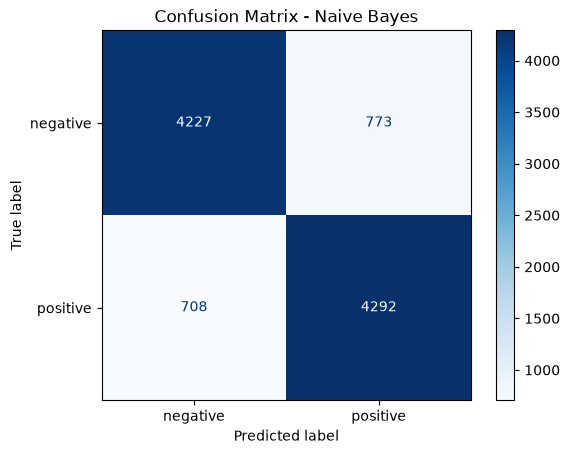

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=naive_bayes.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Naive Bayes")

plt.show()

### Observation

The Multinomial Naive Bayes model achieved an accuracy of **85.19%** on the test dataset.

The precision, recall, and F1-score for both sentiment classes are well balanced, indicating that the model performs consistently for both positive and negative reviews.

The confusion matrix shows that most reviews were classified correctly, while a smaller number of reviews were misclassified due to overlapping language and contextual ambiguity.

## Model 2: Logistic Regression

The second model used is **Logistic Regression**, a linear classification algorithm widely used for sentiment analysis and text classification tasks.

It often performs well with TF-IDF features because it learns a weight for each feature, helping distinguish positive and negative reviews effectively.

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [29]:
logistic_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [30]:
lr_predictions = logistic_model.predict(X_test)

In [31]:
lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")

Logistic Regression Accuracy: 0.8868


In [32]:
print(classification_report(
    y_test,
    lr_predictions
))

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [33]:
lr_cm = confusion_matrix(
    y_test,
    lr_predictions
)

lr_cm

array([[4376,  624],
       [ 508, 4492]])

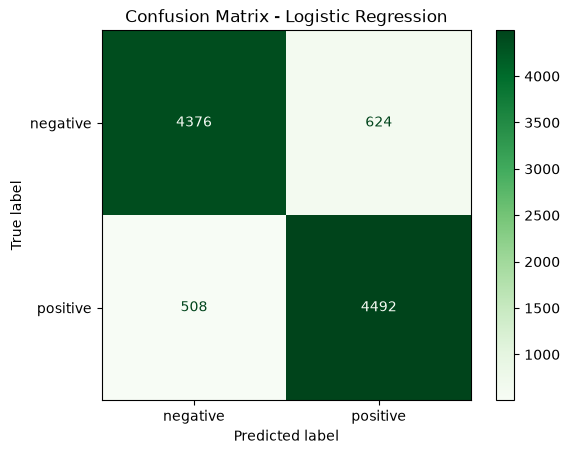

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=logistic_model.classes_
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [35]:
comparison_df = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Naive Bayes,0.8519
1,Logistic Regression,0.8868


In [36]:
from train_model import save_model

In [37]:
save_model(
    logistic_model,
    "../models/sentiment_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


## Conclusion

Two machine learning models were trained and evaluated using TF-IDF features extracted from the cleaned IMDb movie reviews.

The performance comparison showed that **Logistic Regression** achieved the highest accuracy and was selected as the final sentiment classification model.

The trained model and TF-IDF vectorizer were saved for deployment in the next phase of the project.